# Diabetes Risk — Professional EDA & Predictive Baseline

**Objective:** Perform a reproducible, professional data-analyst workflow on `diabetes_risk.csv`: data audit, quality checks, exploratory analysis, statistical association tests, classification baselines, evaluation, feature importance, and actionable analytical next steps.

> **Scope:** `diabetes_risk` is treated as an existing label. This notebook is for analytical/modeling purposes and is **not a medical diagnosis or clinical decision tool**.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, chi2_contingency
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("diabetes_risk.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/diabetes_risk.csv")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Loaded: diabetes_risk.csv
Shape: 15,000 rows × 19 columns


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.500,Yes,Sedentary,Vegetarian,Never,Never,9.000,8,178,7.300,146,90,107.100,High,Low
1,2,53,Female,Mumbai,20.500,Yes,Moderate,Vegetarian,Never,Never,7.000,6,152,6.900,156,100,93.800,Low,Low
2,3,47,Male,Thane,31.300,No,Moderate,Non-Vegetarian,Current,Regular,7.000,7,168,6.600,150,102,113.500,Low,High
3,4,41,Male,Bengaluru,22.800,No,Sedentary,Non-Vegetarian,Never,Never,9.000,5,155,6.700,126,92,109.600,Middle,Low
4,5,57,Female,Bengaluru,16.700,No,Sedentary,Non-Vegetarian,Current,Occasional,6.500,10,188,6.700,130,90,80.800,High,Low


## 1. Structural audit

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "unique_n": df.nunique(dropna=True)
})
print("Duplicate rows:", df.duplicated().sum())
display(audit.sort_values("missing_pct", ascending=False).round(2))

target_dist = df["diabetes_risk"].value_counts().rename_axis("risk").to_frame("count")
target_dist["pct"] = target_dist["count"].div(len(df)).mul(100)
print("\nTarget distribution:")
display(target_dist.round(2))

Duplicate rows: 0


,dtype,missing_n,missing_pct,unique_n
alcohol_consumption,str,3788,25.250,3
smoking_status,str,472,3.150,3
income_bracket,str,463,3.090,3
gender,str,0,0.000,3
age,int64,0,0.000,58
patient_id,int64,0,0.000,15000
city,str,0,0.000,18
physical_activity_level,str,0,0.000,3
family_history_diabetes,str,0,0.000,2
diet_type,str,0,0.000,4



Target distribution:


,count,pct
risk,,
Low,9000,60.000
Moderate,3750,25.000
High,2250,15.000


### Data-quality decisions

- `patient_id` is an identifier and will be excluded from predictive modeling.
- Duplicate rows are checked explicitly.
- Missing categorical values are retained and handled through model pipelines.
- Potential numeric outliers are flagged rather than automatically removed.

## 2. Missingness analysis

,missing_pct
alcohol_consumption,25.250
smoking_status,3.150
income_bracket,3.090


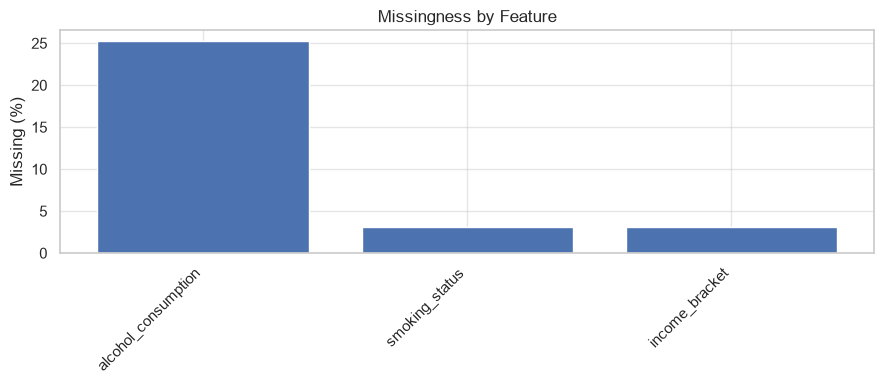

In [3]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0].rename("missing_pct").to_frame()

if missing.empty:
    print("No missing values detected.")
else:
    display(missing.round(2))
    plt.figure(figsize=(9, 4))
    plt.bar(missing.index.astype(str), missing["missing_pct"].values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing (%)")
    plt.xlabel("")
    plt.title("Missingness by Feature")
    plt.tight_layout()
    plt.show()

## 3. Univariate EDA — numerical variables

,count,mean,std,min,25%,50%,75%,max,missing,skew
age,"15,000.000",44.330,10.380,18.000,38.000,45.000,52.000,80.000,0,-0.330
bmi,"15,000.000",23.060,4.050,15.000,20.100,22.700,25.600,40.800,0,0.520
hours_sleep_per_night,"15,000.000",7.310,1.110,3.000,6.700,7.000,8.000,12.000,0,-0.010
stress_level,"15,000.000",5.940,2.150,1.000,4.000,6.000,7.000,10.000,0,-0.100
fasting_blood_sugar,"15,000.000",168.790,38.370,72.000,145.000,165.000,189.000,400.000,0,0.850
hba1c_level,"15,000.000",6.880,0.840,4.800,6.300,6.800,7.300,13.400,0,0.880
blood_pressure_systolic,"15,000.000",139.500,12.660,80.000,130.000,140.000,150.000,200.000,0,-0.010
blood_pressure_diastolic,"15,000.000",86.260,8.390,50.000,80.000,88.000,90.000,120.000,0,0.040
waist_circumference_cm,"15,000.000",100.210,10.760,73.200,92.500,99.300,106.900,148.200,0,0.480


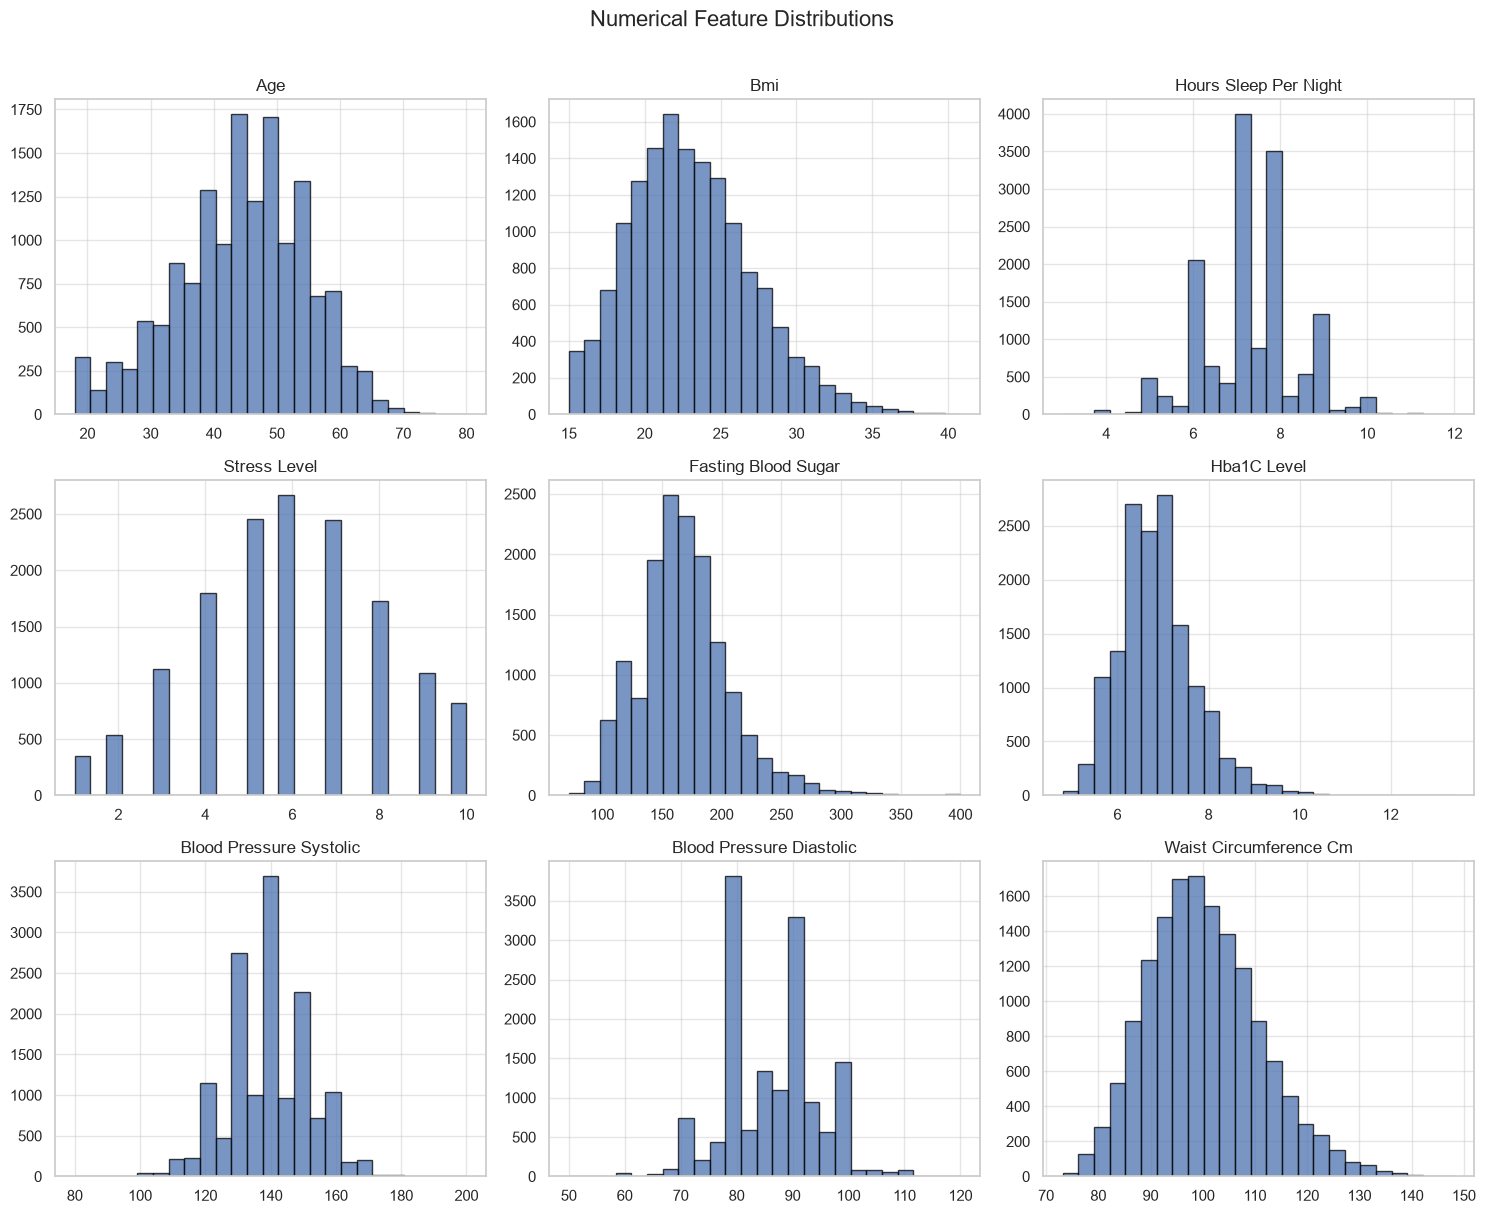

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c != "patient_id"]

summary = df[numeric_features].describe().T
summary["missing"] = df[numeric_features].isna().sum()
summary["skew"] = df[numeric_features].skew()
display(summary[["count","mean","std","min","25%","50%","75%","max","missing","skew"]].round(2))

ncols = 3
nrows = int(np.ceil(len(numeric_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.asarray(axes).reshape(-1)
for ax, col in zip(axes, numeric_features):
    ax.hist(df[col].dropna(), bins=25, edgecolor="black", alpha=0.75)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
for ax in axes[len(numeric_features):]:
    ax.axis("off")
plt.suptitle("Numerical Feature Distributions", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## 4. Outlier screening

,feature,q1,q3,lower_fence,upper_fence,outlier_n,outlier_pct
4,fasting_blood_sugar,145.000,189.000,79.000,255.000,432,2.880
2,hours_sleep_per_night,6.700,8.000,4.750,9.950,360,2.400
5,hba1c_level,6.300,7.300,4.800,8.800,355,2.370
7,blood_pressure_diastolic,80.000,90.000,65.000,105.000,213,1.420
8,waist_circumference_cm,92.500,106.900,70.900,128.500,167,1.110
1,bmi,20.100,25.600,11.850,33.850,153,1.020
6,blood_pressure_systolic,130.000,150.000,100.000,180.000,11,0.070
0,age,38.000,52.000,17.000,73.000,3,0.020
3,stress_level,4.000,7.000,-0.500,11.500,0,0.000


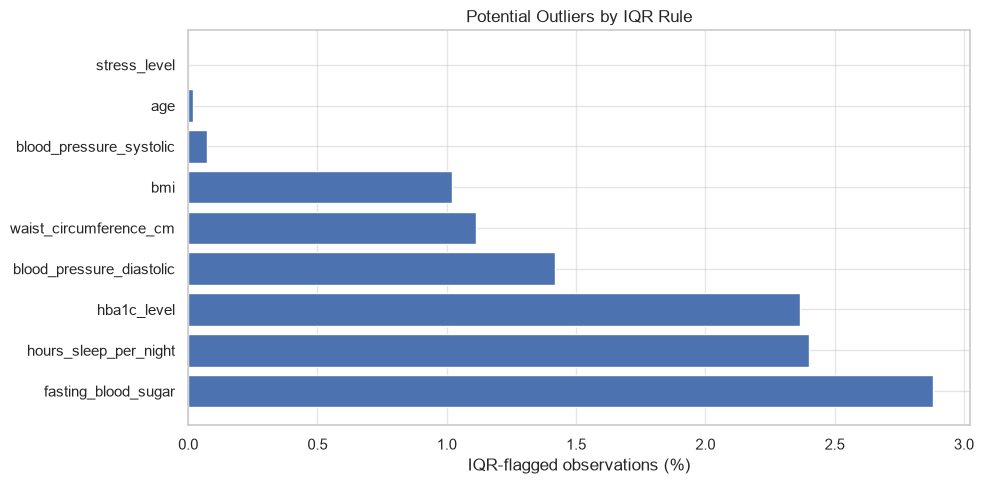

In [5]:
outlier_rows = []
for col in numeric_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "feature": col,
        "q1": q1, "q3": q3,
        "lower_fence": lower, "upper_fence": upper,
        "outlier_n": int(mask.sum()),
        "outlier_pct": mask.mean()*100
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_table.round(2))

plt.figure(figsize=(10, 5))
plt.barh(outlier_table["feature"], outlier_table["outlier_pct"])
plt.xlabel("IQR-flagged observations (%)")
plt.ylabel("")
plt.title("Potential Outliers by IQR Rule")
plt.tight_layout()
plt.show()

## 5. Univariate EDA — categorical variables

In [6]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_features = [c for c in categorical_cols if c != "diabetes_risk"]

for col in categorical_features:
    print(f"\n{col}")
    table = (
        df[col].value_counts(dropna=False)
        .rename_axis(col).to_frame("count")
        .assign(pct=lambda x: x["count"].div(len(df)).mul(100))
    )
    display(table.round(2))


gender


,count,pct
gender,,
Male,7664,51.090
Female,7183,47.890
Other,153,1.020



city


,count,pct
city,,
Mumbai,2243,14.950
Delhi,1737,11.580
Bengaluru,1535,10.230
Hyderabad,1227,8.180
Ahmedabad,1039,6.930
Chennai,933,6.220
Kolkata,872,5.810
Pune,756,5.040
Surat,734,4.890



family_history_diabetes


...

,count,pct
smoking_status,,
Never,10119,67.460
Current,2946,19.640
Former,1463,9.750
NaN,472,3.150



alcohol_consumption


,count,pct
alcohol_consumption,,
Never,5616,37.440
Occasional,4483,29.890
NaN,3788,25.250
Regular,1113,7.420



income_bracket


,count,pct
income_bracket,,
Middle,7305,48.700
High,3844,25.630
Low,3388,22.590
NaN,463,3.090


## 6. Target-focused EDA

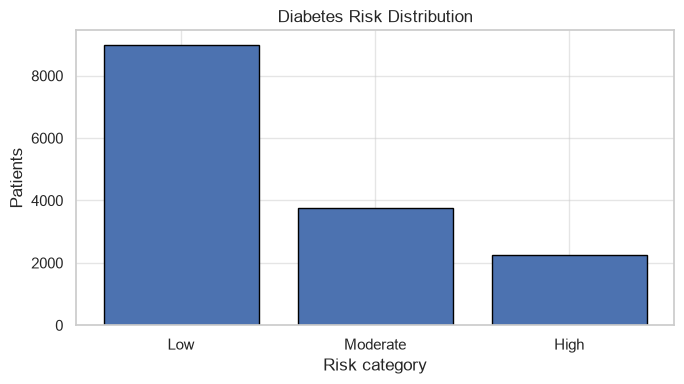

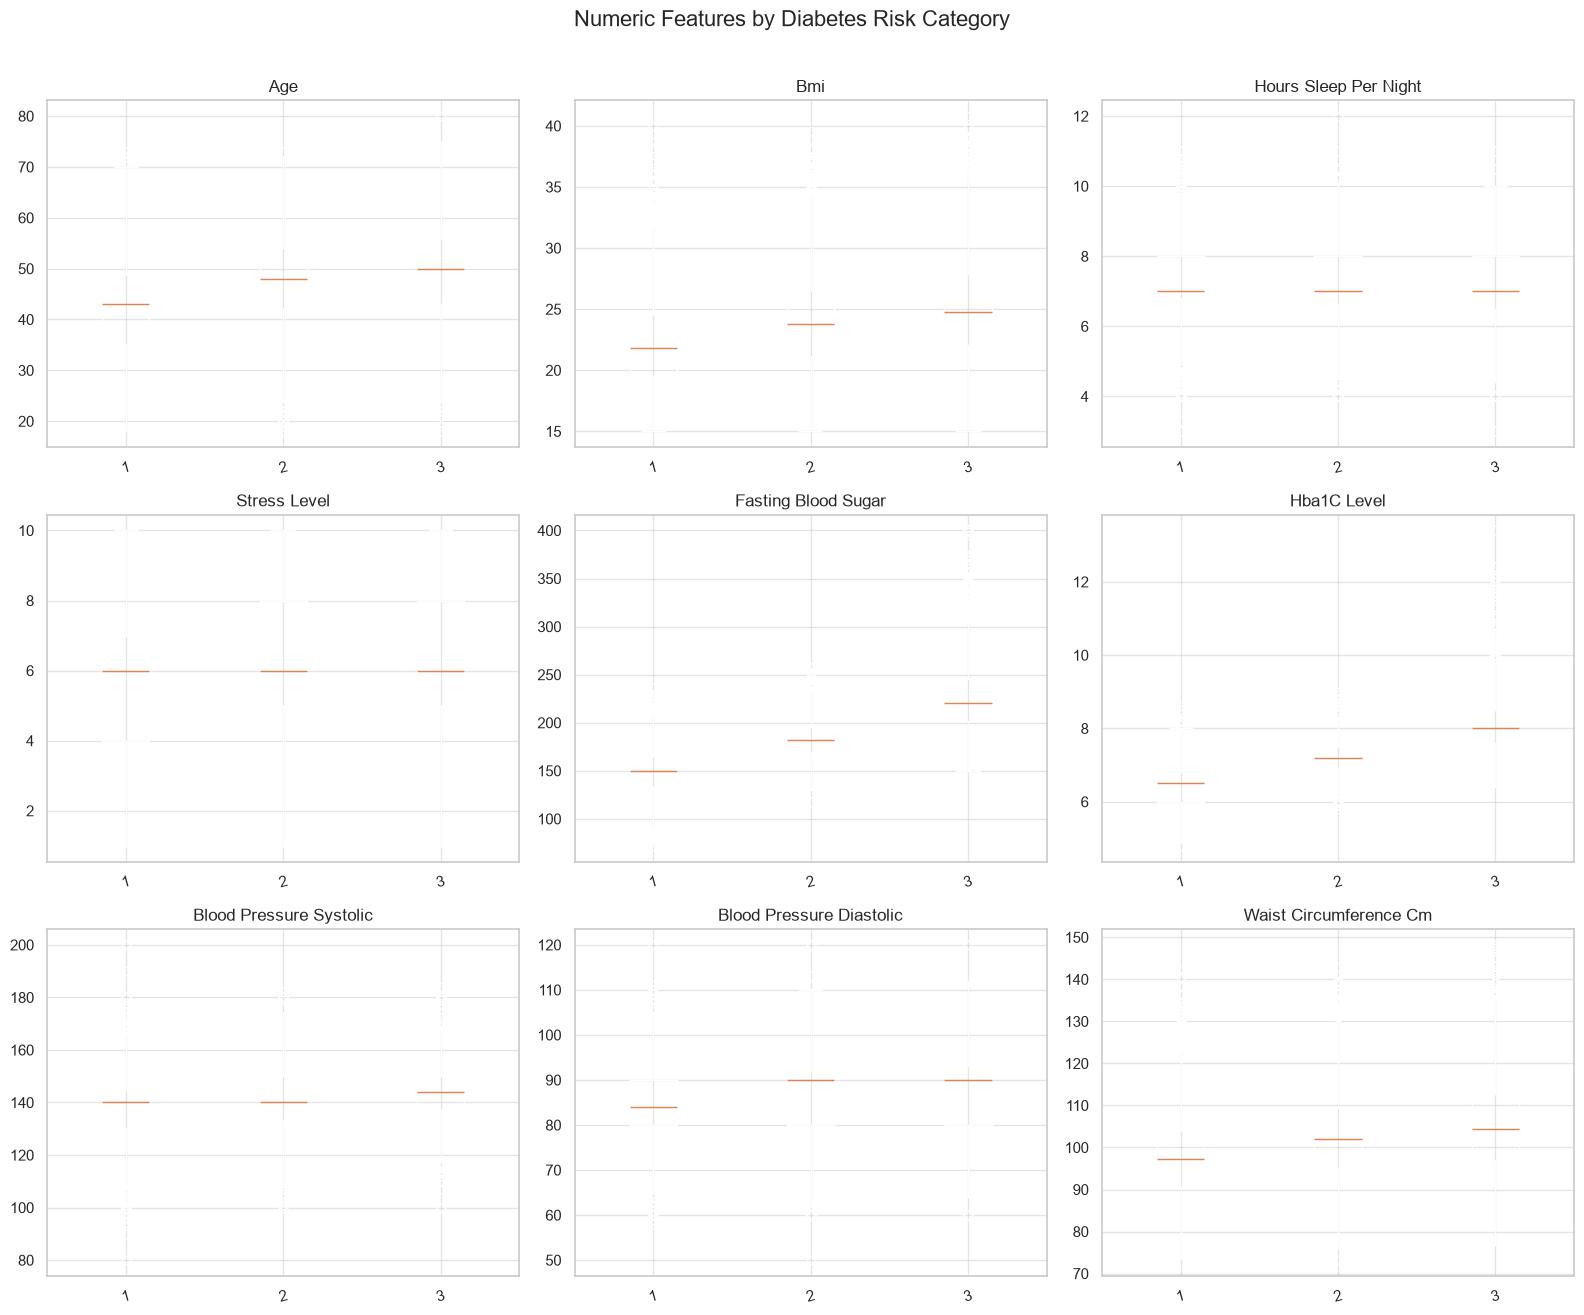

In [7]:
plt.figure(figsize=(7, 4))
counts = df["diabetes_risk"].value_counts().reindex(["Low", "Moderate", "High"])
plt.bar(counts.index, counts.values, edgecolor="black")
plt.title("Diabetes Risk Distribution")
plt.xlabel("Risk category")
plt.ylabel("Patients")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.ravel(), numeric_features):
    groups = [df.loc[df["diabetes_risk"] == r, col].dropna() for r in ["Low", "Moderate", "High"]]
    ax.boxplot(groups, label=["Low", "Moderate", "High"])
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
for ax in axes.ravel()[len(numeric_features):]:
    ax.axis("off")
plt.suptitle("Numeric Features by Diabetes Risk Category", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

diabetes_risk,Low,Moderate,High
age,43.000,48.000,50.000
bmi,21.800,23.800,24.800
hours_sleep_per_night,7.000,7.000,7.000
stress_level,6.000,6.000,6.000
fasting_blood_sugar,150.000,182.000,220.000
hba1c_level,6.500,7.200,8.000
blood_pressure_systolic,140.000,140.000,144.000
blood_pressure_diastolic,84.000,90.000,90.000
waist_circumference_cm,97.200,102.000,104.500


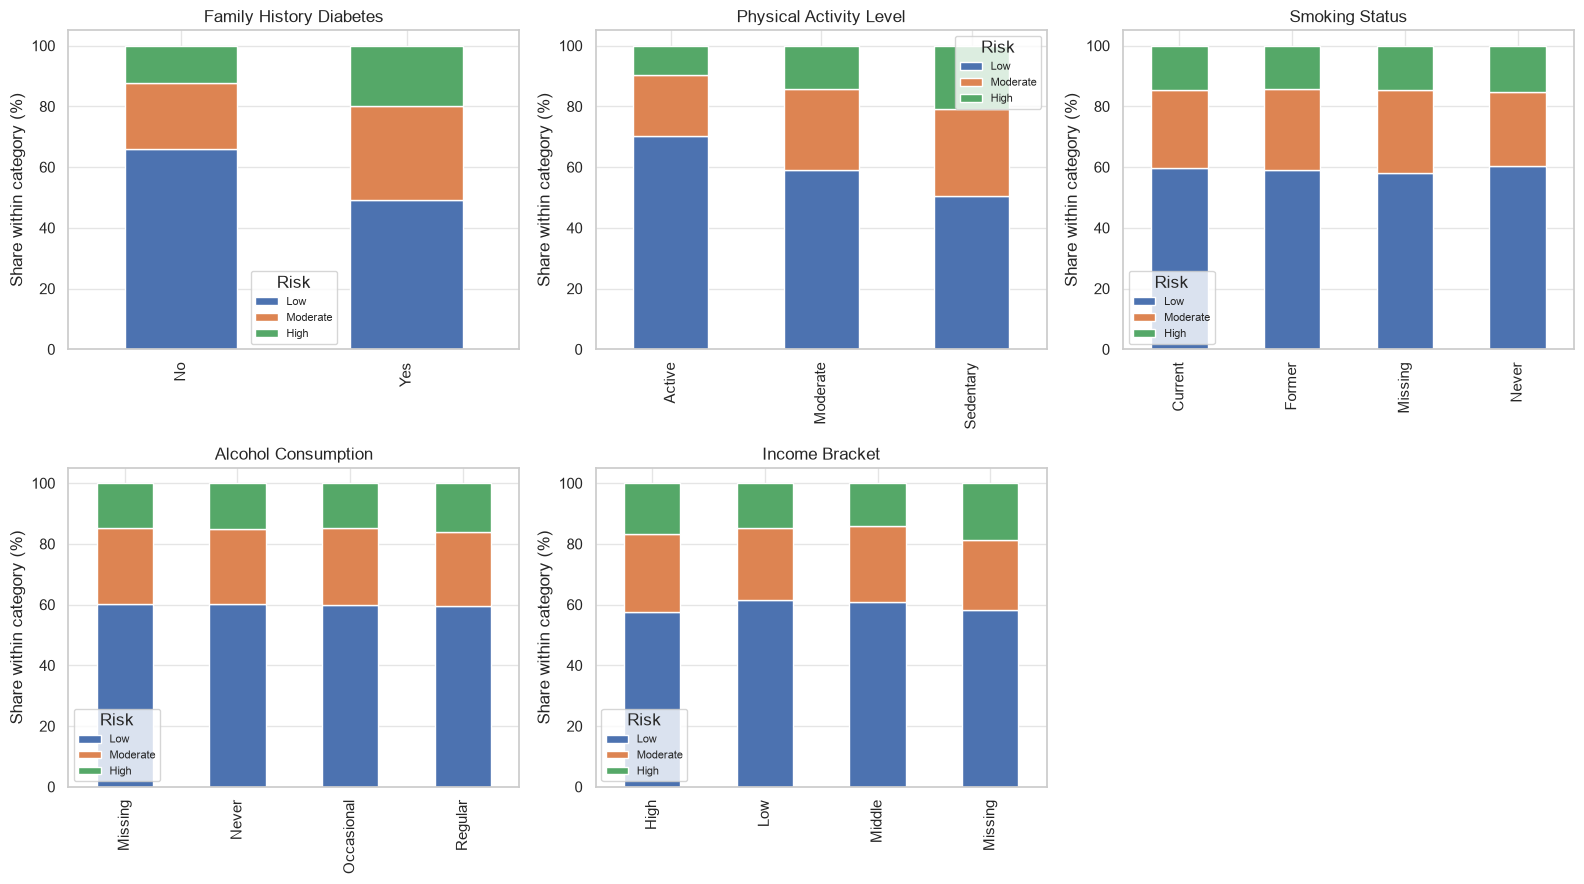

In [8]:
group_profile = df.groupby("diabetes_risk")[numeric_features].median().T
display(group_profile[["Low", "Moderate", "High"]].round(2))

selected_cats = [
    "family_history_diabetes", "physical_activity_level",
    "smoking_status", "alcohol_consumption", "income_bracket"
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), selected_cats):
    rate = pd.crosstab(
        df[col].fillna("Missing"), df["diabetes_risk"], normalize="index"
    ).mul(100)
    rate.reindex(columns=["Low","Moderate","High"], fill_value=0).plot(
        kind="bar", stacked=True, ax=ax
    )
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Share within category (%)")
    ax.set_xlabel("")
    ax.legend(title="Risk", fontsize=8)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

## 7. Correlation and multicollinearity review

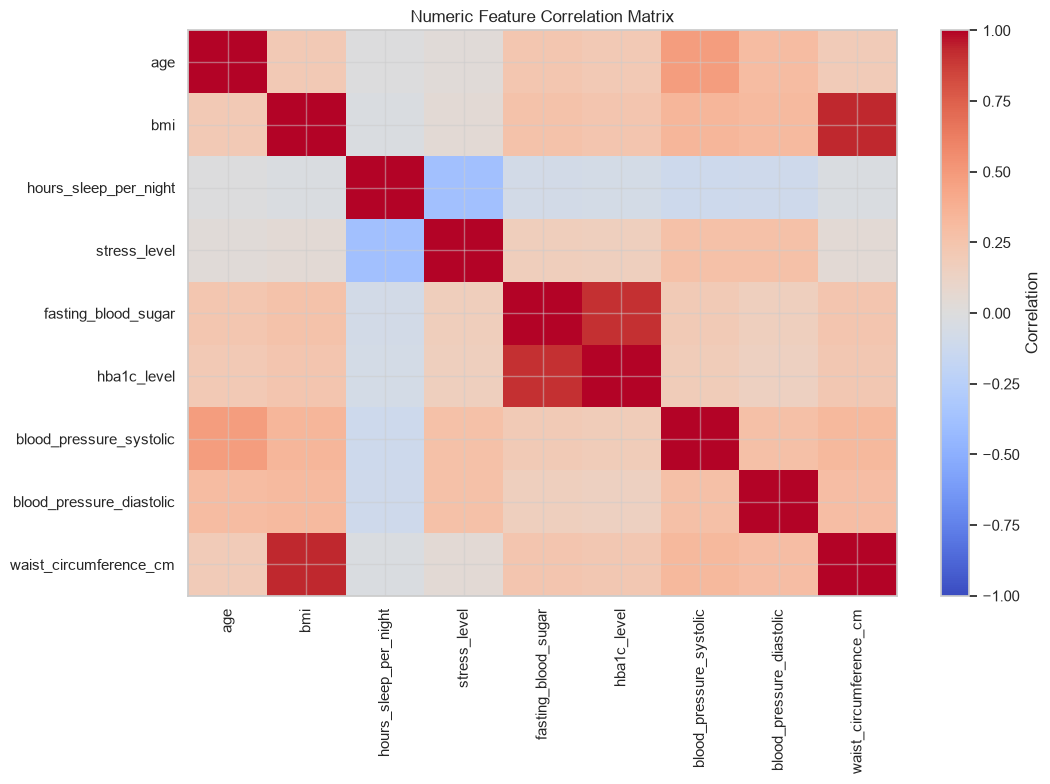

,feature_1,feature_2,correlation,abs_correlation
14,bmi,waist_circumference_cm,0.936,0.936
26,fasting_blood_sugar,hba1c_level,0.913,0.913
5,age,blood_pressure_systolic,0.479,0.479
15,hours_sleep_per_night,stress_level,-0.380,0.380
12,bmi,blood_pressure_systolic,0.342,0.342
34,blood_pressure_systolic,waist_circumference_cm,0.322,0.322
13,bmi,blood_pressure_diastolic,0.314,0.314
6,age,blood_pressure_diastolic,0.304,0.304
35,blood_pressure_diastolic,waist_circumference_cm,0.296,0.296
33,blood_pressure_systolic,blood_pressure_diastolic,0.278,0.278


In [9]:
corr = df[numeric_features].corr()
plt.figure(figsize=(11, 8))
im = plt.imshow(corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

pairs = []
for i, a in enumerate(numeric_features):
    for b in numeric_features[i+1:]:
        pairs.append((a, b, corr.loc[a, b]))
strong_pairs = pd.DataFrame(
    pairs, columns=["feature_1","feature_2","correlation"]
)
strong_pairs["abs_correlation"] = strong_pairs["correlation"].abs()
display(strong_pairs.sort_values("abs_correlation", ascending=False).head(10).round(3))

## 8. Statistical association tests

- **Kruskal–Wallis**: numerical feature vs. the three risk groups.
- **Chi-square test of independence**: categorical feature vs. risk group.
- **Benjamini–Hochberg FDR correction**: controls false discovery rate across multiple tests.

A significant association is not evidence of causation.

In [10]:
kw_results = []
for col in numeric_features:
    groups = [g[col].dropna().values for _, g in df.groupby("diabetes_risk")]
    stat, p = kruskal(*groups)
    kw_results.append({
        "feature": col, "test": "Kruskal-Wallis",
        "statistic": stat, "p_value": p
    })

chi_results = []
for col in categorical_features:
    table = pd.crosstab(df[col].fillna("Missing"), df["diabetes_risk"])
    stat, p, dof, expected = chi2_contingency(table)
    chi_results.append({
        "feature": col, "test": "Chi-square",
        "statistic": stat, "p_value": p, "dof": dof
    })

test_results = pd.DataFrame(kw_results + chi_results)
test_results["q_value"] = multipletests(
    test_results["p_value"], method="fdr_bh"
)[1]
test_results["significant_fdr_5pct"] = test_results["q_value"] < 0.05
display(test_results.sort_values("q_value").round(6))

,feature,test,statistic,p_value,dof,q_value,significant_fdr_5pct
5,hba1c_level,Kruskal-Wallis,"7,817.122",0.000,NaN,0.000,True
4,fasting_blood_sugar,Kruskal-Wallis,"8,072.753",0.000,NaN,0.000,True
0,age,Kruskal-Wallis,"1,334.173",0.000,NaN,0.000,True
1,bmi,Kruskal-Wallis,"1,192.563",0.000,NaN,0.000,True
8,waist_circumference_cm,Kruskal-Wallis,"1,015.482",0.000,NaN,0.000,True
6,blood_pressure_systolic,Kruskal-Wallis,694.543,0.000,NaN,0.000,True
12,physical_activity_level,Chi-square,453.489,0.000,4.000,0.000,True
7,blood_pressure_diastolic,Kruskal-Wallis,423.163,0.000,NaN,0.000,True
11,family_history_diabetes,Chi-square,402.297,0.000,2.000,0.000,True
3,stress_level,Kruskal-Wallis,162.923,0.000,NaN,0.000,True


## 9. Modeling setup

In [11]:
target = "diabetes_risk"
X = df.drop(columns=[target, "patient_id"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

models = {
    "Dummy baseline": Pipeline([
        ("prep", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "Logistic regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Random forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400, random_state=42,
            class_weight="balanced", n_jobs=-1, min_samples_leaf=3
        ))
    ])
}

print("Train:", X_train.shape, " Test:", X_test.shape)
display(y_train.value_counts(normalize=True).rename("share").round(3))

Train: (12000, 17)  Test: (3000, 17)


diabetes_risk
Low        0.600
Moderate   0.250
High       0.150
Name: share, dtype: float64

## 10. Model evaluation

In [12]:
results = []
predictions = {}
probabilities = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predictions[name] = pred

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted")
    }

    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test)
        probabilities[name] = proba
        row["roc_auc_ovr_macro"] = roc_auc_score(
            y_test, proba, multi_class="ovr", average="macro",
            labels=pipe.classes_
        )
    results.append(row)

model_results = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(model_results.round(4))

for name, pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(y_test, pred, digits=3))

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_ovr_macro
1,Logistic regression,0.794,0.731,0.744,0.790,0.916
2,Random forest,0.767,0.742,0.732,0.775,0.908
0,Dummy baseline,0.600,0.333,0.250,0.450,0.500



Dummy baseline
              precision    recall  f1-score   support

        High      0.000     0.000     0.000       450
         Low      0.600     1.000     0.750      1800
    Moderate      0.000     0.000     0.000       750

    accuracy                          0.600      3000
   macro avg      0.200     0.333     0.250      3000
weighted avg      0.360     0.600     0.450      3000


Logistic regression
              precision    recall  f1-score   support

        High      0.818     0.720     0.766       450
         Low      0.860     0.909     0.884      1800
    Moderate      0.601     0.563     0.581       750

    accuracy                          0.794      3000
   macro avg      0.760     0.731     0.744      3000
weighted avg      0.789     0.794     0.791      3000


Random forest
              precision    recall  f1-score   support

        High      0.743     0.747     0.745       450
         Low      0.910     0.816     0.860      1800
    Moderate      0.532

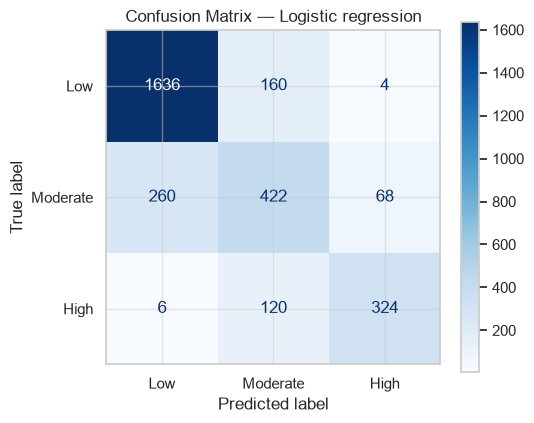

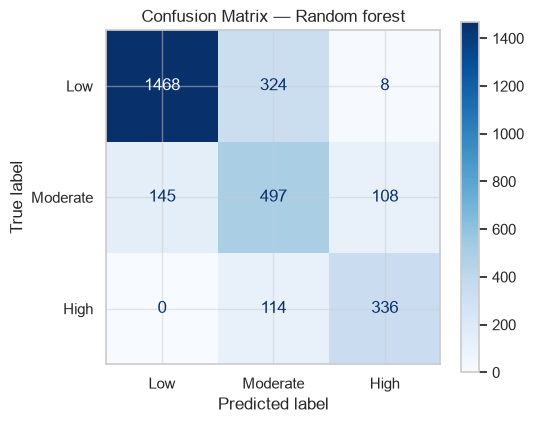

In [13]:
for name in ["Logistic regression", "Random forest"]:
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name],
        labels=["Low", "Moderate", "High"],
        cmap="Blues", values_format="d", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

## 11. Cross-validation robustness check

In [14]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_rows = []

for name in ["Logistic regression", "Random forest"]:
    scores = cross_validate(
        models[name], X, y, cv=cv,
        scoring={
            "macro_f1": "f1_macro",
            "balanced_accuracy": "balanced_accuracy",
            "accuracy": "accuracy"
        },
        n_jobs=-1
    )
    cv_rows.append({
        "model": name,
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_accuracy_mean": scores["test_accuracy"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_macro_f1_mean", ascending=False)
display(cv_results.round(4))

,model,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_accuracy_mean,cv_accuracy_mean
1,Random forest,0.740,0.005,0.750,0.773
0,Logistic regression,0.738,0.001,0.726,0.790


## 12. Model-agnostic feature importance

,feature,importance_mean,importance_std
11,fasting_blood_sugar,0.182,0.009
12,hba1c_level,0.107,0.008
0,age,0.013,0.004
16,income_bracket,0.004,0.002
10,stress_level,0.000,0.002
6,diet_type,-0.000,0.001
7,smoking_status,-0.000,0.001
8,alcohol_consumption,-0.000,0.001
4,family_history_diabetes,-0.001,0.002
14,blood_pressure_diastolic,-0.001,0.002


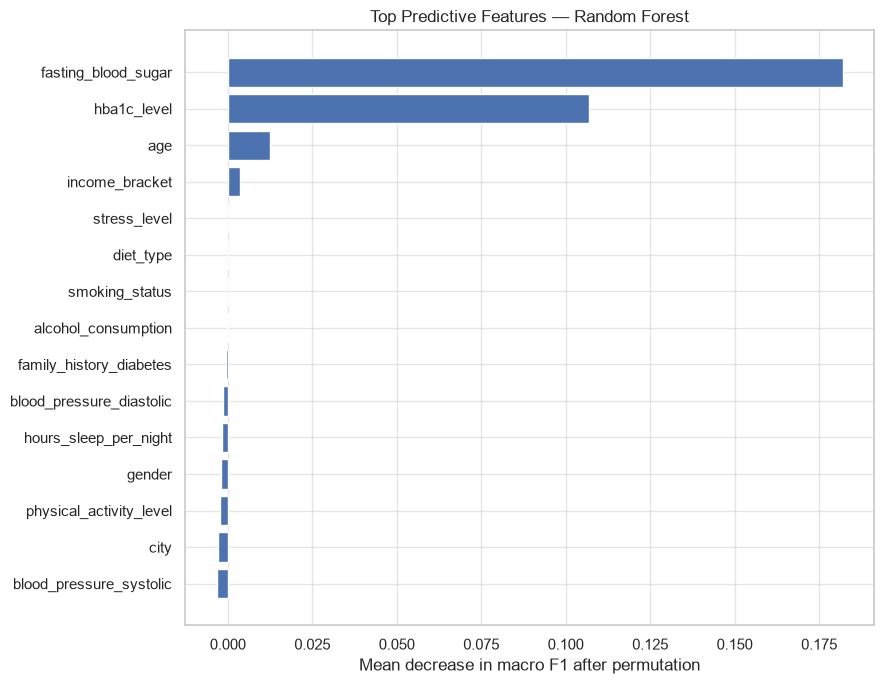

In [15]:
rf = models["Random forest"]
perm = permutation_importance(
    rf, X_test, y_test,
    scoring="f1_macro", n_repeats=8,
    random_state=42, n_jobs=-1
)

importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)
display(importance.head(15).round(4))

plt.figure(figsize=(9, 7))
top_imp = importance.head(15).sort_values("importance_mean")
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.xlabel("Mean decrease in macro F1 after permutation")
plt.ylabel("")
plt.title("Top Predictive Features — Random Forest")
plt.tight_layout()
plt.show()

## 13. Analyst conclusions and next steps

### Key analytical conclusions
- The supplied data contains 15,000 observations and 19 columns, with a three-class `diabetes_risk` target.
- The target is imbalanced, so accuracy alone is not sufficient; macro F1 and balanced accuracy are included.
- Missingness is concentrated in selected categorical variables and is handled reproducibly within the modeling pipeline.
- IQR screening identifies unusual numerical observations. They are **not automatically deleted** because they may represent real high-risk measurements.
- Statistical tests identify associations between the available variables and the risk label, with FDR correction for multiple testing.
- Predictive feature importance indicates which variables contribute most to reproducing the supplied label; this should not be interpreted as causal evidence.

### Recommended next steps
1. Confirm the data dictionary and exact definition of Low/Moderate/High risk.
2. Investigate the reason for substantial missingness in `alcohol_consumption`.
3. Validate extreme glucose, HbA1c, blood-pressure, BMI, and waist measurements against source systems.
4. If dates become available, perform temporal validation rather than relying only on a random split.
5. Compare subgroup performance across relevant demographic and socioeconomic groups.
6. If the target is intentionally ordinal, benchmark ordinal classification methods.
7. Before deployment, document feature definitions, missing-data policy, model version, validation design, and monitoring metrics.

> **Critical modeling caveat:** If `diabetes_risk` was itself constructed from variables such as fasting blood sugar or HbA1c, high model performance may partly reflect label leakage by design. A production model should be evaluated against the actual intended prediction time and information set.\